In [3]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl

import copy

import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src') 
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from data_queries import query_extra_data
from astrometry_equations import angular_distance

In [4]:
#plt.style.available
plt.style.use('default')
mpl.rcParams['axes.grid'] = True
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'serif'
plt.style.use('seaborn-darkgrid')

In [10]:
radius = '1as'
method = 'nearest'
extension = ''

rpath = '../../results/'
fpath = '../../../figures/'
dpath = '../../../data/' 
xm_all = np.load(rpath+f'crossmatch{extension}_{radius}_all_neighbours.npy')
xm_near = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_nearest.npy')
xm_bright = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_brightest.npy')

xm = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_{method}.npy')

In [184]:
# Get Gaia data
extra_gdata = ['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
xm_all, gdata_all = query_extra_data(xm_all, extra_gdata)
xm_near, gdata_near = query_extra_data(xm_near, extra_gdata)
xm_bright, gdata_bright = query_extra_data(xm_bright, extra_gdata)

# Get Hipp data
extra_hdata = ['hp_mag', 'b_v']
xm_all, hdata_all = query_extra_data(xm_all, extra_hdata, cat='hipp')
xm_near, hdata_near = query_extra_data(xm_near, extra_hdata, cat='hipp')
xm_bright, hdata_bright = query_extra_data(xm_bright, extra_hdata, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

## Hipparcos Values Matched vs. Unmatched

In [ ]:
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
hip_ids = hipp['hip']

hip_matched = [] # Appending slow but whatever
hip_nomatch = []

for i,hip in enumerate(hip_ids):
    if hip in xm[:,0]:
        hip_matched.append(i)
    else:
        hip_nomatch.append(i)
hip_matched = np.array(hip_matched)
hip_nomatch = np.array(hip_nomatch)

In [ ]:
print(f"Number of matched Hipparcos stars: {hip_matched.shape[0]}")
print(f"Number of unmatched Hipparcos stars: {hip_nomatch.shape[0]}")

In [ ]:
# Compare histograms of magnitude
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(hipp['hp_mag'][hip_matched], histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(hipp['hp_mag'][hip_nomatch], histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Hp Magnitude')
ax.set_ylabel('log Counts')
ax.set_title(f"Hp Histogram (r={radius}, method={method})")
ax.invert_xaxis()

plt.legend()
plt.show()

In [ ]:
# Compare histogram of proper mitions
pm_matched = np.sqrt((hipp['pm_ra'][hip_matched]**2.) + (hipp['pm_de'][hip_matched]**2))
pm_nomatch = np.sqrt((hipp['pm_ra'][hip_nomatch]**2.) + (hipp['pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(pm_matched), histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Total Proper Motion (milli-arcsecond / year)')
ax.set_ylabel('log Counts')
ax.set_title(f"Log Total Proper Motion Histogram")


plt.legend()
plt.show()

In [ ]:
# Compare histogram of proper motion errors
e_pm_matched = np.sqrt((hipp['e_pm_ra'][hip_matched]**2.) + (hipp['e_pm_de'][hip_matched]**2))
e_pm_nomatch = np.sqrt((hipp['e_pm_ra'][hip_nomatch]**2.) + (hipp['e_pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(e_pm_matched),histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(e_pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Log Total Proper Motion Error (milli-arcsecond / year)')

ax.set_ylabel('log Counts')
ax.set_title(f"Proper motion error Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

## Gaia properties of Matched objects

In [ ]:
match_method = 'nearest'
print(extra_gdata)
print(extra_hdata)
hipp_bv = hdata_near[:,1]
hp_mag = hdata_near[:,0]
gaia_g = gdata_near[:,0]

In [ ]:
# G - Hp relation reported on the gaia archive doccs
x = np.linspace(np.min(hipp_bv), np.max(hipp_bv), 1000)
y = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3)
sigma = 0.02417

fig, ax = plt.subplots(1,1, figsize=(8, 6))
bv0_mask = np.where(hipp_bv==0.)

scatter = ax.scatter(hipp_bv, gaia_g-hp_mag, s=2, c=gaia_g)
ax.scatter(hipp_bv[bv0_mask], (gaia_g-hp_mag)[bv0_mask], s=2, c='red', label='B-V = 0')
ax.plot(x,y,c='black',ls='--', label=f"H$_p$ - G relation")
ax.fill_between(x,y-sigma,y+sigma, color='gray', label=f'$1\sigma$')
cb = plt.colorbar(scatter)
cb.set_label(f"H$_p$  Magnitude")

ax.set_ylabel(f"H$_p$ - G")
ax.set_xlabel("Hipparcos B-V")
ax.set_title(f"Gaia - Hipparcos Magnitude Relation ({match_method})")

plt.legend()

plt.savefig(fpath+'gaiapred_bvcol.png', bbox_inches='tight')
plt.show()

The white line is the assumption we have made for the limit of the magnitude of Gaia objects, this line should perfectly match with the observations if this relation exactly holds. If an object lies above this black line, then Hp - G is bigger, and thus the Gaia star is brighter. If the star is below the line, then the Gaia star is less bright then we had assumed

In [ ]:
# Difference between G_pred and matched G
x = hipp_bv
G_pred = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3) + hp_mag
best_line = np.arange(min(gaia_g), max(gaia_g))

fig, ax = plt.subplots(1,1, figsize=(8,6))

scatter = ax.scatter(gaia_g, G_pred, s=2, c=hipp_bv)
cb = plt.colorbar(scatter)
cb.set_label("Hipparcos B-V")
ax.plot(best_line, best_line, c='black', label="Perfect Prediction")

ax.set_xlabel("G")
ax.set_ylabel("G$_{pred}$")
ax.set_title(f"Predicted G vs. Matched G ({match_method})")
ax.invert_xaxis()
ax.invert_yaxis()


plt.legend()
plt.savefig(fpath+'gaiapred_gaiamatch.png', bbox_inches='tight')
plt.show()

In [11]:
pos_gaia_params_full = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop', 'ra', 'dec', 'pmra', 'pmdec']
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']
xm = xm_all

#xm, pos_gaia = query_extra_data(xm, pos_gaia_params, cat='GaiaBaseCat', cat_dpath='../../../data/')
# Difficult to query Gaia data because the cat file is too big.

_, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')
print(extension)
cat_gaia = fits.open(f'../../../data/GaiaBaseCat{extension}.fits')[1].data
# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
#pos_gaia_table_full = np.zeros((xm.shape[0], len(pos_gaia_params_full)))
for i, label in enumerate(pos_gaia_params):
    pos_gaia_table[:, i] = cat_gaia[label][xm[:,2]]

#for i, label in enumerate(pos_gaia_params_full):
    #pos_gaia_table_full[:, i] = cat_gaia[label][xm[:,2]]

pos_gaia_table_full = copy.deepcopy(cat_gaia)
pos_gaia_table_full = pos_gaia_table_full[xm[:,2]]

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.



In [ ]:
# Manual cross match on a Gaia Cat. This is incredibly slow. Should be able to do this better.
# For nearest implementation. Do it only for those objects where it is necessary
# The below code is for a full run.
pos_gaia = np.zeros((xm.shape[0], len(pos_gaia_params)))
for i,gaia_id in enumerate(xm[:,1]):
    cat_idx = np.where(cat_gaia['source_id'] == gaia_id)
    for j, label in enumerate(pos_gaia_params):
        pos_gaia[i][j] = cat_gaia[cat_idx][label]
    print(f'{i}/{xm.shape[0]}', end='\r')

## Plotting of sky regions around Hipparcos object

In [12]:
# The indexing here is absolutely terrible. But it works
# Plot double candidate stars
u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

random_choice = np.random.choice(doubles)
#random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]
print(c[random_idx])
gaia_ids = xm[idx[random_idx]:idx[random_idx]+c[random_idx]][:,1]
#pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]
pos_gaia = pos_gaia_table_full[idx[random_idx]: idx[random_idx] + c[random_idx]]



#gaia_ids = []
#pos_gaia = np.zeros((c[random_idx], len(pos_gaia_params)+1))
#
#for i in range(c[random_idx]):
#    gaia_cat_idx = np.where(cat_gaia['source_id'] == xm[idx[random_idx]+i][1])
#
#    for j, label in enumerate(pos_gaia_params):
#        pos_gaia[i][j] = cat_gaia[gaia_cat_idx][label]
#    pos_gaia[i][-1] = xm[random_idx+i][1]

2


In [ ]:
gaia_ids

[              63307 6081295738319706368             6011736]
6081295738319706368
6081295738309765248


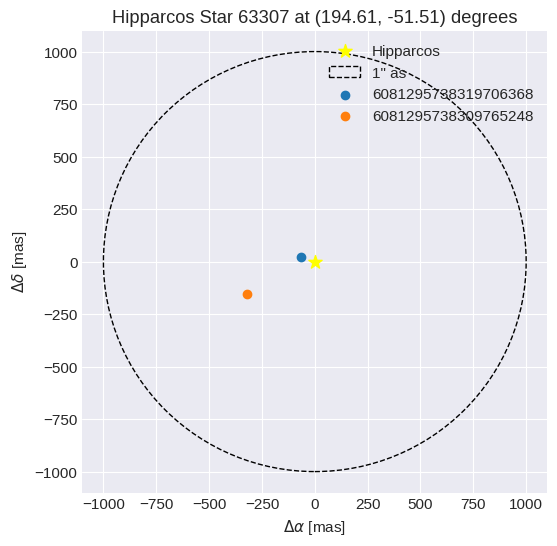

Distance between Gaia and Hipparcos object is 69.60 mas
This corresponds to 100.2527195558259 sigma_hipparcos.


In [13]:
# Plot star + error bars for randomly chosen object
ei = 1 # error inflation for testing

u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

random_choice = np.random.choice(doubles)
#random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]

gaia_ids = xm[idx[random_idx]:idx[random_idx]+c[random_idx]][:,1]
pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]

from matplotlib.patches import Circle, Ellipse
print(xm[idx[random_idx]])

cs_radius = 1
fig, ax = plt.subplots(1,1, figsize=(6,6))

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3

ax.scatter(0, 0, s=100, c='yellow', marker='*',label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='yellow')
ax.add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
ax.add_patch(conesearch_circle)

for i,pos in enumerate(pos_gaia):
    print(gaia_ids[i])
    ra = pos[0] * 3600 * 1e3
    de = pos[1] * 3600 * 1e3
    ax.scatter(ra - ra_h, de - de_h,  label=np.int64(gaia_ids[i]), c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos[2], ei*pos[3], fill=False, color=f'C{i}')

    ax.add_patch(gaia_err_ellipse)

ax.set_xlabel(r"$\Delta\alpha$ [mas]")
ax.set_ylabel(r"$\Delta\delta$ [mas]")
ax.set_title(f"Hipparcos Star {hipp_id} at ({pos_hipp[0]:.2f}, {pos_hipp[1]:.2f}) degrees")

#plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')

#sq_scale = 5 # mas
#ax.set_xlim(-sq_scale, +sq_scale)
#ax.set_ylim(-sq_scale, +sq_scale)

#plt.savefig('../../../figures/example_skyplot_sigma_zoomed.png', bbox_inches='tight')

plt.legend()
plt.show()


ra_h = np.radians(pos_hipp[0])
de_h = np.radians(pos_hipp[1])
ra_g = np.radians(pos_gaia[0][0])
de_g = np.radians(pos_gaia[0][1])

factor1 = (ra_h - ra_g) * np.cos(np.radians(de_h))
factor2 = de_h - de_g
distance = np.sqrt((factor1 ** 2) + (factor2 ** 2))
distance_mas = 3600 * 1e3 * np.degrees(distance)

avg_hipp_error = (1./np.sqrt(2)) * np.sqrt(pos_hipp[2]**2 + pos_hipp[3]**2)
error_w_distance = distance_mas/avg_hipp_error # avg_hipp_error is supposed to be in mas

print(f"Distance between Gaia and Hipparcos object is {distance_mas:.2f} mas")
print(f"This corresponds to {error_w_distance} sigma_hipparcos.")

#dist = angular_distance2(pos_hipp[0], pos_hipp[1], pos_gaia[0][0], pos_gaia[0][1], unit='degrees')


1.173993944038054
0.05632177740335465
-46.893746989936076 -1.1741038374432065
0.0 0.0


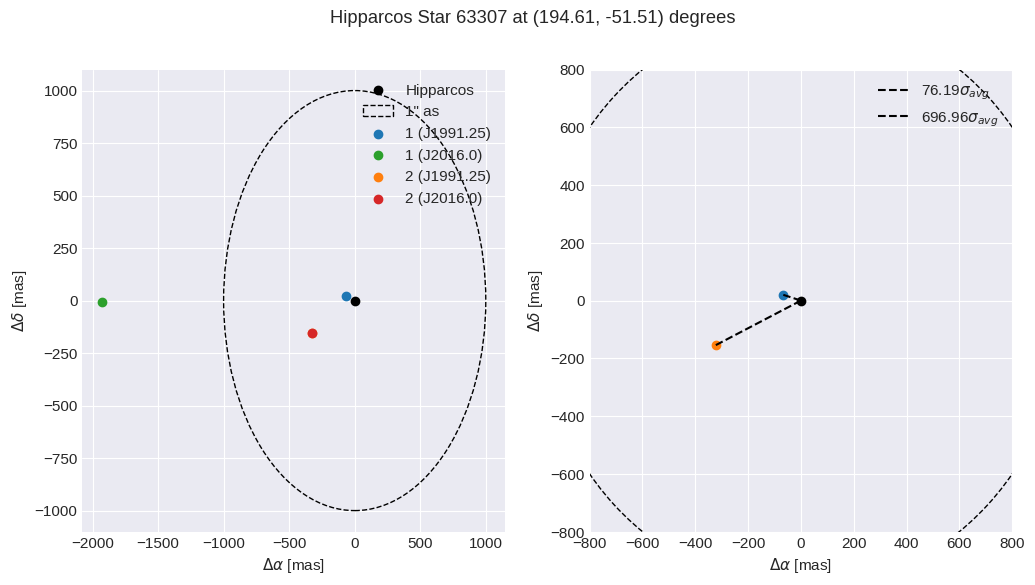

In [23]:
# Plot for presentation of Gaia propagation
ei = 1 # error inflation for testing

cs_radius = 1
fig, axs = plt.subplots(1,2, figsize=(12,6))

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3
avg_hipp_er = np.sqrt((pos_hipp[2])**2 + (pos_hipp[3])**2)

# Left Square
axs[0].scatter(0, 0, c='black',label='Hipparcos', zorder=3)
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='yellow')
axs[0].add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
axs[0].add_patch(conesearch_circle)


for i,pos in enumerate(pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx]]):
    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    axs[0].scatter(ra - ra_h, de - de_h,  label=f'{i+1} (J1991.25)', c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos['e_ra_prop'], ei*pos['e_de_prop'], 
                               fill=False, color=f'C{i}')
    axs[0].add_patch(gaia_err_ellipse)
      
    ra = pos['ra'] * 3600 * 1e3
    de = pos['dec'] * 3600 * 1e3
    axs[0].scatter(ra - ra_h, de - de_h, label=f'{i+1} (J2016.0)', c=f'C{i+2}')
    
    #axs[0].arrow(ra-ra_h, de-de_h, pos['pmra'], pos['pmdec'], color=f'C{i+2}', head_width=50)
    print(pos['e_ra_prop'])

#sq_scale = 1000 # mas
#axs[0].set_xlim(-sq_scale, +sq_scale)
#axs[0].set_ylim(-sq_scale, +sq_scale)

# Right square
axs[1].scatter(0, 0, c='black')#,label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='black')
axs[1].add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--')#, label=f'{cs_radius}" as')
axs[1].add_patch(conesearch_circle)

for i,pos in enumerate(pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx] ]):

    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    axs[1].scatter(ra - ra_h, de - de_h, c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos['e_ra_prop'], ei*pos['e_de_prop'], 
                           fill=False, color=f'C{i}')
    axs[1].add_patch(gaia_err_ellipse)
    
    avg_gaia_error = (1./np.sqrt(2)) * np.sqrt((pos['e_ra_prop']**2) + (pos['e_de_prop']**2))
    avg_error = (1./np.sqrt(2)) * np.sqrt((avg_gaia_error**2) + (avg_hipp_er)**2)

    distance = np.sqrt((ra-ra_h)**2 + (de-de_h)**2)
    ew_distance = distance/avg_error

    axs[1].plot([0,ra-ra_h],[0,de-de_h], c='black', ls='--', label=f'{ew_distance:.2f}'+r'$\sigma_{avg}$')
    print(pos['pmra_prop'], pos['pmdec_prop'])

#plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')

sq_scale = 800 # mas
axs[1].set_xlim(-sq_scale, +sq_scale)
axs[1].set_ylim(-sq_scale, +sq_scale)

#plt.savefig('../../../figures/example_skyplot_sigma_zoomed.png', bbox_inches='tight')

for ax in axs:
    ax.set_xlabel(r"$\Delta\alpha$ [mas]")
    ax.set_ylabel(r"$\Delta\delta$ [mas]")
    ax.legend()
plt.suptitle(f"Hipparcos Star {hipp_id} at ({pos_hipp[0]:.2f}, {pos_hipp[1]:.2f}) degrees")
plt.savefig(fpath+'example_skypiece', bbox_inches='tight', transparent=True)
plt.show()



#dist = angular_distance2(pos_hipp[0], pos_hipp[1], pos_gaia[0][0], pos_gaia[0][1], unit='degrees')

#### List all of the properties of the two matched objects above. For the extra data querying, the above is of course done from '_all'

In [24]:
from astrometry_equations import predict_G_bv
fits.open(f'../../../data/GaiaBaseCat{extension}.fits')[1].data

FITS_rec([( 498895983697735552,  78.51864764,  72.10596783,  0.37262797, -0.01167932, 0.42987322,  78.5186393 ,  72.10596791, 0.42987279,  0.37262722, -0.01167925, -8.44896386e+00, 0.21675663, 0.27225867, -0.03651706, 12.448798, 1.3214092 ),
          (5727850956699814272, 121.90287833, -11.77536725, -2.1558217 , -5.56010539, 2.43312328, 121.90289347, -11.77532903, 2.43312461, -2.15582374, -5.56011156,  4.53855548e+00, 0.56079725, 0.35262137,  0.11283269, 12.448798, 0.83098507),
          (5871959856985072000, 205.53367502, -57.23771953, -9.71854928, -5.56734984, 1.28528854, 205.53379849, -57.23768126, 1.28528781, -9.7185282 , -5.56736115, -4.71401910e+00, 0.28853187, 0.42419222,  0.01694337, 12.448799, 0.5458517 ),
          ...,
          (4151144444902586368, 270.96502343, -11.36503621,  3.31486083,  4.86413558, 0.99520506, 270.96500019, -11.36506965, 0.99520296,  3.31484721,  4.86411475, -1.76147856e+01, 0.4390558 , 0.34611451,  0.25114155, 13.372266, 1.8997717 ),
          (595509

In [195]:
## TEMPORARY (UNTILL JUPYTER RELOAD)
def predict_G_bv(hp_mag, b_v):
    return -0.02392 - 0.4069 * b_v + 0.04569 * (b_v**2) - 0.0452 * (b_v**3) + hp_mag

In [210]:
gaia_data = pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx] ]
hipp_data = pos_hipp_table[idx[random_idx]]
hipp_extra = hdata_all[idx[random_idx]]
print(extra_hdata)
print(hipp_data, hipp_extra)
print(gaia_data)
print(gaia_data[0]['pmra'])

['hp_mag', 'b_v']
[3.26372448e+02 6.77513084e+01 8.30000000e-01 6.60000000e-01
 2.30000000e-01] [8.3406 0.085 ]
[(2222846172131802880, 326.37222575, 67.75131213, 1.e+20, 1.e+20, 1.e+20, 326.37222575, 67.75131213, 0., 0., 0., 0., 7.72924566, 6.52243185, -0.92881495, 9.151779, 0.14960194)
 (2222846167832799488, 326.37249568, 67.75130111, 1.e+20, 1.e+20, 1.e+20, 326.37249568, 67.75130111, 0., 0., 0., 0., 0.90600795, 0.97117794,  0.25041616, 8.830912, 0.1406107 )]
1e+20


0.0

In [212]:
# Overview

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3
avg_hipp_er = np.sqrt((pos_hipp[2])**2 + (pos_hipp[3])**2)

print(f"""Hipparcos Object:
Hipparcos Magnitude: {hipp_extra[0]}
B-V Colour:          {hipp_extra[1]}
Predicted Gaia Mag.: {predict_G_bv(hipp_extra[0], hipp_extra[1]):.2f}""")

print('---------------------------')


for i in range(gaia_data.shape[0]):
    pos = gaia_data[i]

    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    era, ede = pos['e_ra_prop'], pos['e_de_prop']

    avg_gaia_error = np.sqrt((era**2) + (ede**2))
    avg_error = np.sqrt((avg_gaia_error**2) + (avg_hipp_er)**2)

    distance = np.sqrt((ra-ra_h)**2 + (de-de_h)**2)
    ew_distance = distance/avg_error

    print(f"""Gaia Match {i+1}:
    Avg. Sigma Distance: {ew_distance:.1f} sigma
    Gaia Magnitude:      {pos['phot_g_mean_mag']:.2f}
    Bp - Rp colour:      {pos['bp_rp']:.2f}""")

Hipparcos Object:
Hipparcos Magnitude: 8.3406
B-V Colour:          0.085
Predicted Gaia Mag.: 8.28
---------------------------
Gaia Match 1:
    Avg. Sigma Distance: 78.5 sigma
    Gaia Magnitude:      9.15
    Bp - Rp colour:      0.15
Gaia Match 2:
    Avg. Sigma Distance: 103.2 sigma
    Gaia Magnitude:      8.83
    Bp - Rp colour:      0.14


## Investigate distances between matches

In [55]:
def gaussian(x, mu, sigma, amp):
    return amp/(sigma * 2 * np.pi) * np.exp(-0.5*((x-mu)**2.)/sigma**2)

from scipy.optimize import curve_fit

In [90]:
print(pos_hipp_params)
print(pos_gaia_params)
print(pos_gaia_table.shape)
print(xm.shape)

['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']
['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop']
(117705, 5)
(117705, 3)


In [71]:

distances = angular_distance(pos_hipp_table[:,0], pos_hipp_table[:,1], pos_gaia_table[:,0], pos_gaia_table[:,1], unit='degrees')
distances_mas = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table[:, 2])**2 + (pos_gaia_table[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances = distances_mas / avg_errors

In [86]:
print(f"Average Hipparcos Uncertainty is {np.mean(avg_hipp_errors):.2f} mas")
print(f"Average Gaia Uncertainty is      {np.mean(avg_gaia_errors):.2f} mas")

Average Hipparcos Uncertainty is 0.81 mas
Average Gaia Uncertainty is      1.15 mas


In [108]:
#from astroquery.gaia import Gaia
from data_queries import gaia_login, launch_job, get_data
job = 'select ra_error, dec_error from gaiadr3.gaia_source where phot_g_mean_mag < 14'
gaia_login()
query = launch_job(job)
gaia_uncertainties = get_data(query)

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
INFO: Query finished. [astroquery.utils.tap.core]


(array([1.19000e+02, 3.02600e+03, 2.40420e+04, 8.13460e+04, 1.39911e+05,
        1.69567e+05, 1.87864e+05, 1.30121e+05, 7.58480e+04, 4.52090e+04,
        3.05560e+04, 2.31270e+04, 1.81210e+04, 1.41300e+04, 1.11130e+04,
        8.67900e+03, 6.97600e+03, 5.40600e+03, 4.42400e+03, 3.43200e+03,
        2.77600e+03, 2.10800e+03, 1.72500e+03, 1.28000e+03, 1.03600e+03,
        7.89000e+02, 6.56000e+02, 5.73000e+02, 5.96000e+02, 5.18000e+02,
        5.16000e+02, 5.36000e+02, 5.24000e+02, 5.06000e+02, 5.64000e+02,
        5.40000e+02, 4.53000e+02, 3.65000e+02, 2.92000e+02, 2.24000e+02,
        1.33000e+02, 9.50000e+01, 5.90000e+01, 4.30000e+01, 2.50000e+01,
        1.70000e+01, 9.00000e+00, 1.10000e+01, 6.00000e+00, 8.00000e+00]),
 array([-5.535891  , -5.333668  , -5.131446  , -4.929223  , -4.727     ,
        -4.5247774 , -4.322555  , -4.1203322 , -3.9181094 , -3.7158868 ,
        -3.5136642 , -3.3114414 , -3.1092188 , -2.906996  , -2.7047734 ,
        -2.5025506 , -2.300328  , -2.0981054 , -1

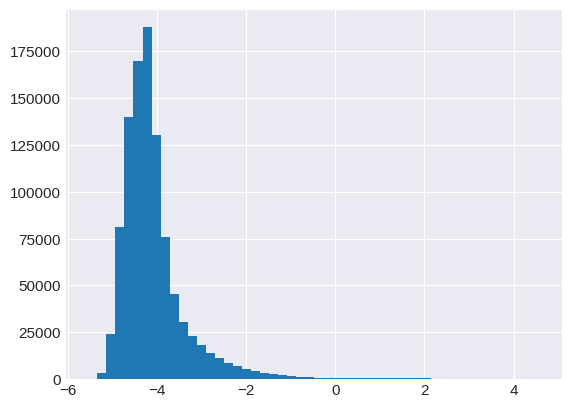

In [107]:
plt.hist(np.log(gaia_uncertainties['ra_error']),bins=50)

(array([2.0000e+00, 2.0000e+00, 3.0000e+00, 3.0000e+00, 3.0000e+00,
        2.0000e+00, 4.0000e+00, 9.0000e+00, 5.0000e+00, 7.0000e+00,
        1.4000e+01, 1.7000e+01, 1.6200e+02, 1.1730e+03, 4.1250e+03,
        8.7210e+03, 1.4113e+04, 1.6972e+04, 1.5869e+04, 1.2805e+04,
        8.6490e+03, 5.9400e+03, 4.1820e+03, 3.3320e+03, 2.7430e+03,
        2.5170e+03, 2.2510e+03, 2.0910e+03, 1.9660e+03, 1.6440e+03,
        1.4830e+03, 1.2160e+03, 1.0850e+03, 9.6600e+02, 7.8900e+02,
        6.9200e+02, 5.4500e+02, 4.5800e+02, 3.7000e+02, 3.2900e+02,
        2.2500e+02, 1.3200e+02, 3.2000e+01, 1.6000e+01, 1.3000e+01,
        9.0000e+00, 9.0000e+00, 3.0000e+00, 4.0000e+00, 3.0000e+00]),
 array([-1.4953132 , -1.42896679, -1.36262039, -1.29627399, -1.22992758,
        -1.16358118, -1.09723477, -1.03088837, -0.96454197, -0.89819556,
        -0.83184916, -0.76550275, -0.69915635, -0.63280994, -0.56646354,
        -0.50011714, -0.43377073, -0.36742433, -0.30107792, -0.23473152,
        -0.16838512, -0.10

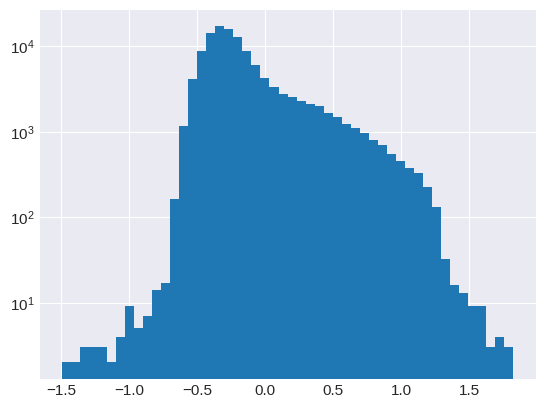

In [95]:
plt.hist(np.log10(avg_gaia_errors), log=True, bins=50)

(array([2.0000e+00, 1.6000e+01, 5.4000e+01, 1.0800e+02, 1.8900e+02,
        3.5100e+02, 5.2700e+02, 8.5300e+02, 1.5090e+03, 2.3160e+03,
        4.2400e+03, 6.2920e+03, 9.7040e+03, 1.2777e+04, 1.5476e+04,
        1.6520e+04, 1.4281e+04, 1.0936e+04, 7.3360e+03, 4.7900e+03,
        3.1280e+03, 1.9990e+03, 1.3020e+03, 8.5300e+02, 6.0100e+02,
        3.3000e+02, 2.8700e+02, 1.7700e+02, 1.6400e+02, 1.2500e+02,
        1.0800e+02, 1.0600e+02, 7.1000e+01, 5.5000e+01, 3.8000e+01,
        2.6000e+01, 1.9000e+01, 1.5000e+01, 1.1000e+01, 6.0000e+00,
        0.0000e+00, 3.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-1.18580553, -1.11977126, -1.05373698, -0.98770271, -0.92166843,
        -0.85563416, -0.78959988, -0.72356561, -0.65753133, -0.59149706,
        -0.52546278, -0.4594285 , -0.39339423, -0.32735995, -0.26132568,
        -0.1952914 , -0.12925713, -0.06322285,  0.00281142,  0.0688457 ,
         0.13487998,  0.20

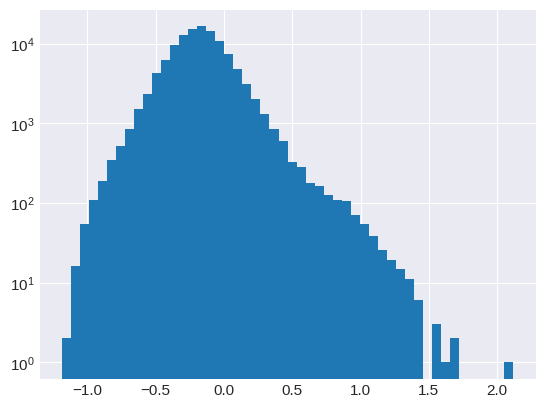

In [96]:
plt.hist(np.log10(avg_hipp_errors), log=True, bins=50)

In [ ]:
#distances = angular_distance(pos_hipp_table[:,0], pos_hipp_table[:,1], pos_gaia_table[:,0], pos_gaia_table[:,1], unit='degrees')
#distances_mas = np.degrees(distances) * 3600 * 1e3
#avg_hipp_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
#error_w_distances = distances_mas / avg_hipp_errors

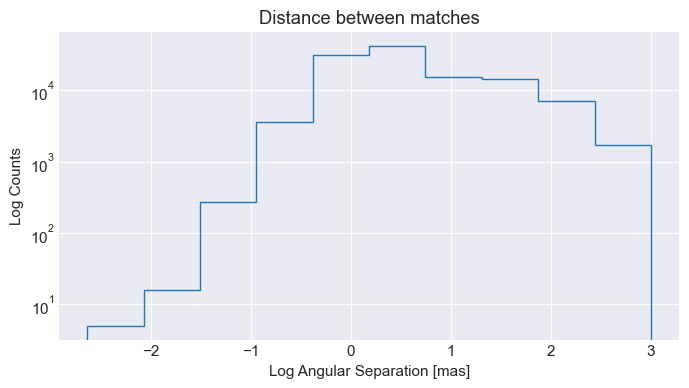

In [49]:
# Distances Histogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(distances_mas), log=True, histtype='step')

ax.set_xlabel("Log Angular Separation [mas]")
ax.set_ylabel("Log Counts")
ax.set_title("Distance between matches")

plt.savefig(fpath+f"xm{extension}_{radius}_nearest_angsep.png", bbox_inches='tight')
plt.show()


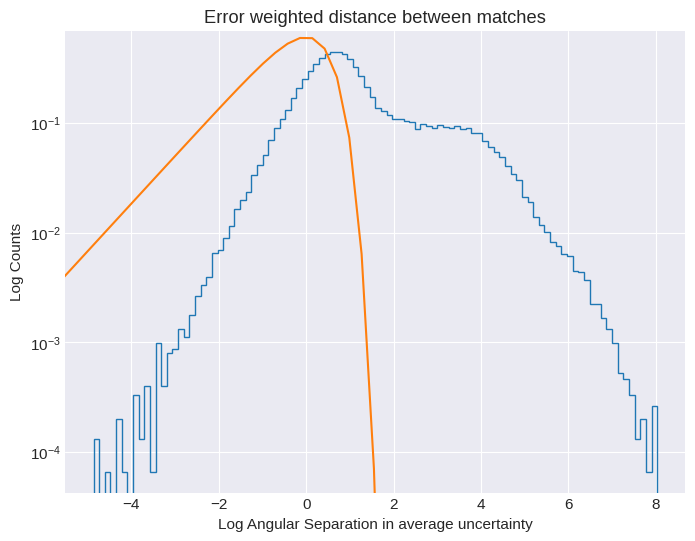

In [82]:
def rayleigh(x, sigma):
    return (x/(sigma**2)) * np.exp(-0.5*((x/sigma)**2.))

# EW Distances Histogram
fig, ax = plt.subplots(1,1, figsize=(8,6))
n, bins, patch = ax.hist(np.log(error_w_distances), bins=100, log=True, histtype='step', density=True)
#print(n, bins)

#ax.hist(error_w_distances)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

x = np.logspace(-3, +3)
#x.plot(np.log(x), gaussian(x, 0, 1, 1))
ax.plot(np.log(x), rayleigh(x, 1))
#popt, pcov = curve_fit(gaussian, bins, n, p0=[1,1,1])


ax.set_xlabel("Log Angular Separation in average uncertainty")
ax.set_ylabel("Log Counts")
ax.set_title("Error weighted distance between matches")

ax.set_xlim(xlim)
ax.set_ylim(ylim)

#plt.savefig(fpath+f"xm{extension}_{radius}_nearest_angsep.png", bbox_inches='tight')
plt.show()


### Do the above code en mass for all four catalogues with an XM at a certain radius

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

...

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


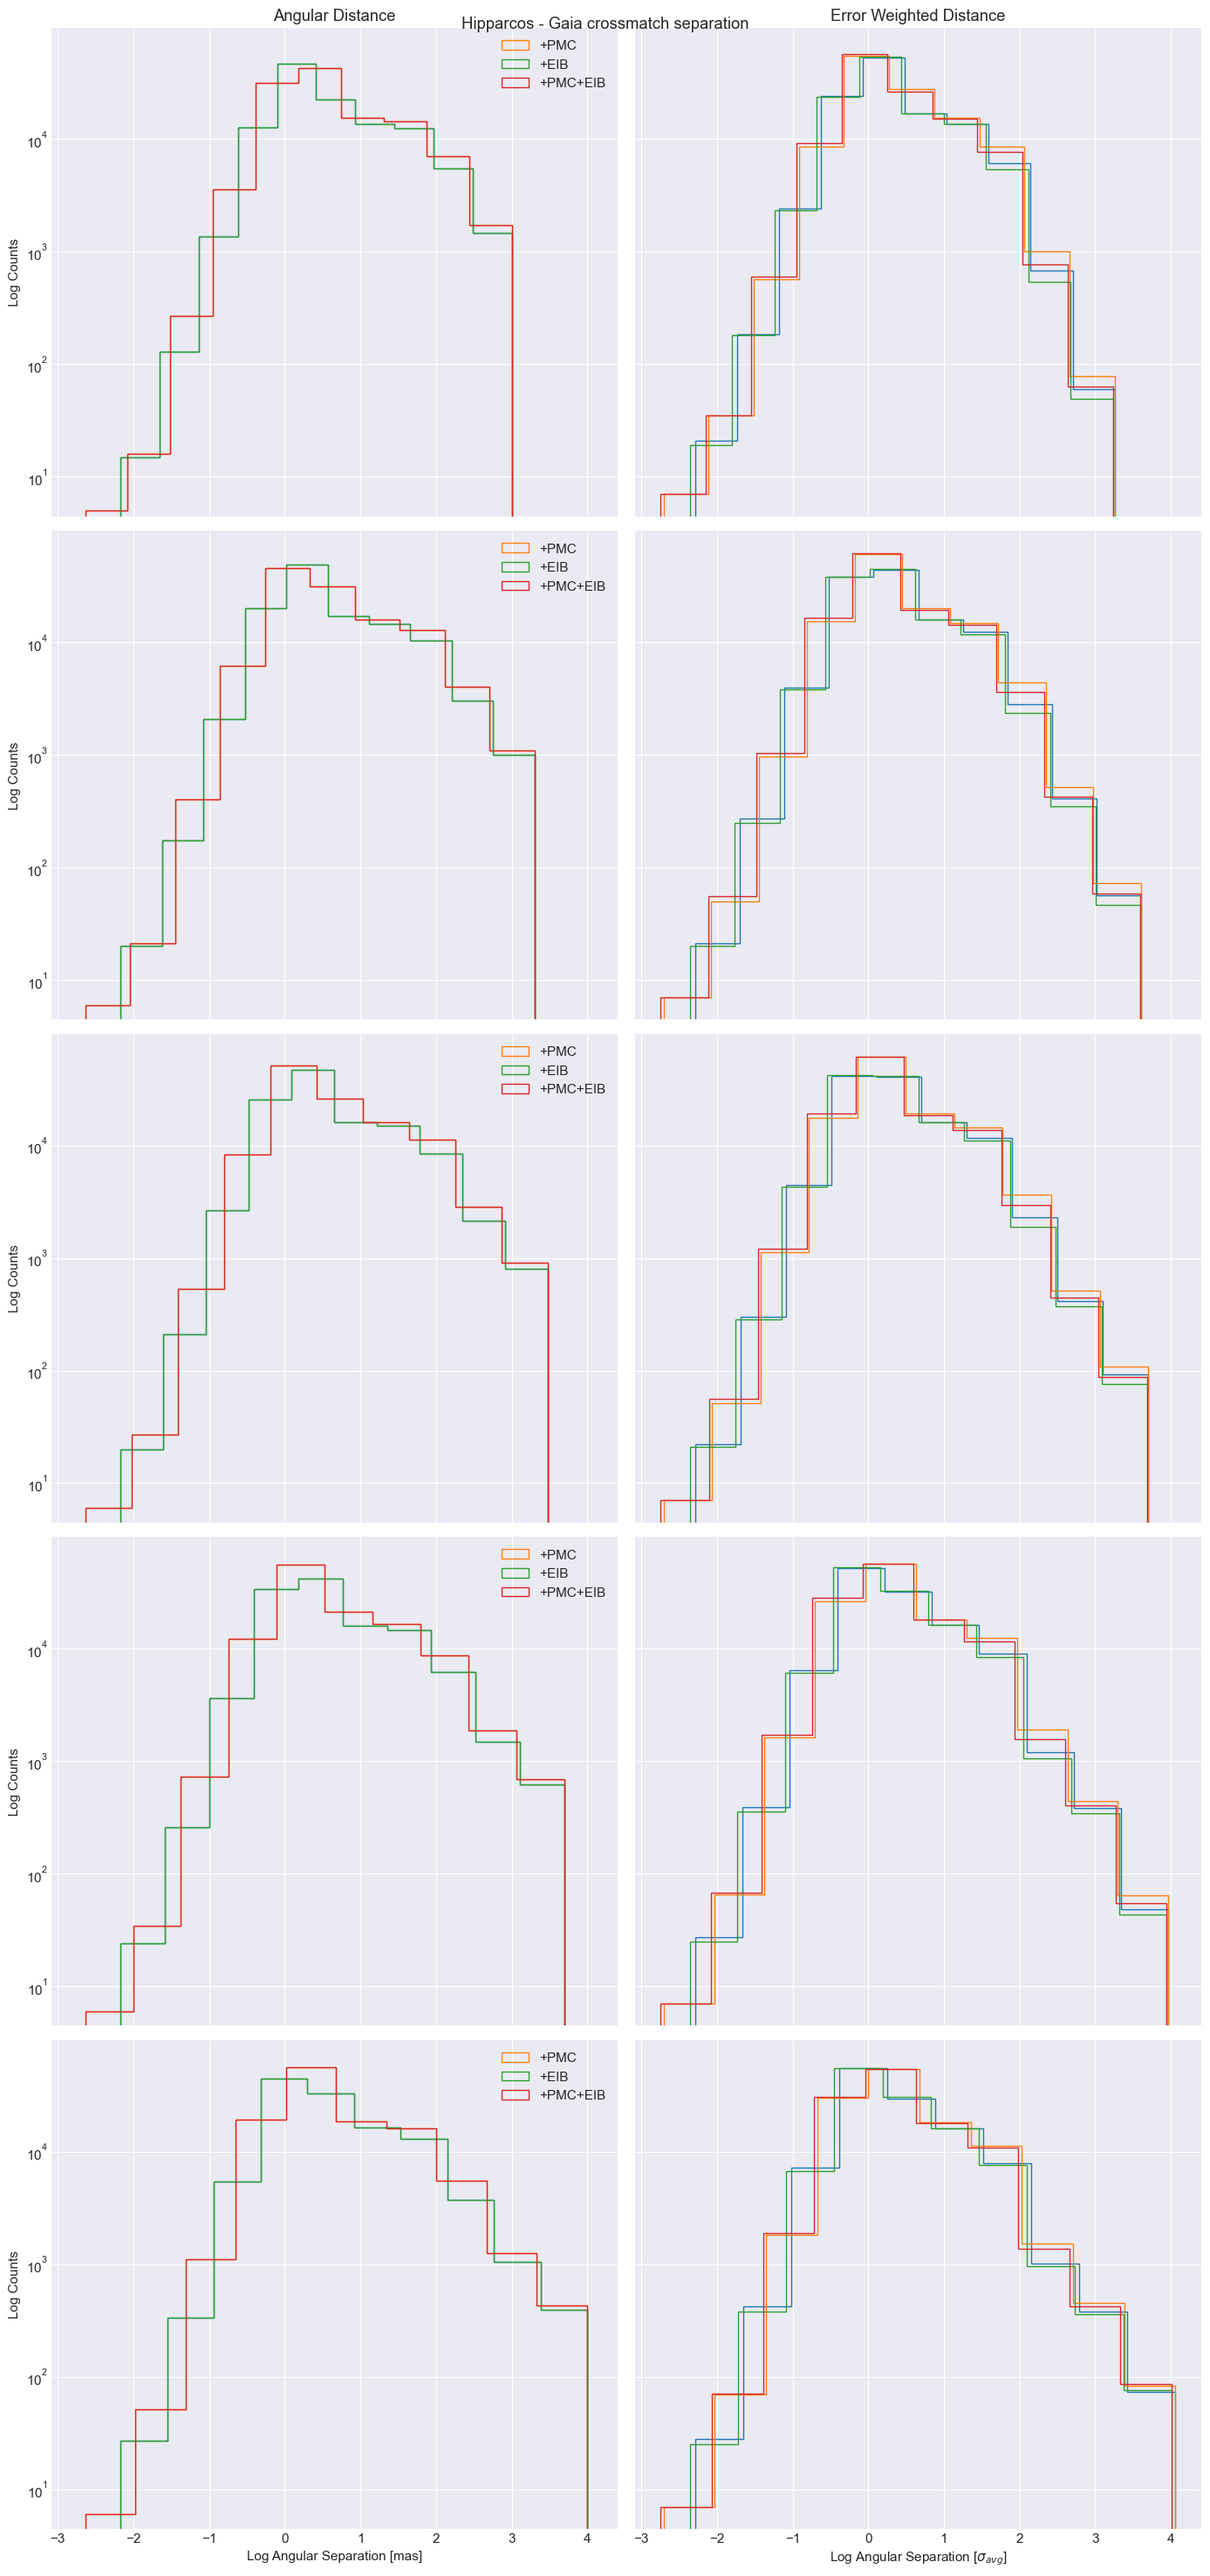

In [112]:
# !TAKE CARE WHEN RUNNING THIS BECAUSE IT WILL MESS WITH THE ABOVE CODE!
extension_types = ['', '+PMC', '+EIB', '+PMC+EIB']
radius = '1as'
method = 'nearest'
radius_ar = ['1as', '2as', '3as', '5as', '10as']

fig, axs = plt.subplots(5,2, figsize=(14,30), sharey=True, sharex=True, tight_layout=True)

# Labelling
axs[4][0].set_xlabel('Log Angular Separation [mas]')
axs[4][1].set_xlabel(r'Log Angular Separation [$\sigma_{avg}$]')

axs[0][0].set_title('Angular Distance')
axs[0][1].set_title('Error Weighted Distance')
plt.suptitle('Hipparcos - Gaia crossmatch separation')



for i, radius in enumerate(radius_ar):
    axs[i][0].set_ylabel('Log Counts')

    for ext in extension_types:
        # Import XM data. xm looks like: [[hip1, source_id1, gaia_cat_id1], [..], ..., [..]]
        xm = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_{method}.npy')

        #Hipp data
        _, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')

        # Create Gaia data table
        cat_gaia = fits.open(f'../../../data/GaiaBaseCat{ext}.fits')[1].data

        # This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
        pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
        for j, label in enumerate(pos_gaia_params):
            pos_gaia_table[:, j] = cat_gaia[label][xm[:,2]]

        # Compute distances + Errors
        pos_hipp_table = pos_hipp_table.astype(float)
        pos_gaia_table = pos_gaia_table.astype(float)

        # Annoying work around below. Some error with wrong data types when doing np.radians on everything at the same time.
        # Below code seems to work properly though
        ra_a = np.radians(pos_hipp_table[:,0])
        dec_a = np.radians(pos_hipp_table[:,1])
        ra_b = np.radians(pos_gaia_table[:,0])
        dec_b = np.radians(pos_gaia_table[:,1])
        distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

        distances_mas = np.degrees(distances) * 3600 * 1e3
        avg_hipp_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
        avg_gaia_errors = np.sqrt((pos_gaia_table[:, 2])**1 + (pos_gaia_table[: ,3])**2)
        avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
        error_w_distances = distances_mas / avg_errors

        # Plotting
        axs[i][0].hist(np.log10(distances_mas), log=True, histtype='step', label=ext)#, bins=20)
        axs[i][1].hist(np.log10(error_w_distances), log=True, histtype='step')#, bins=20)



        axs[i][0].legend()
plt.savefig(fpath+f"crossmatch_separation_all", bbox_inches='tight')

## Crossmatch properties numbers table

In [137]:
# !TAKE CARE WHEN RUNNING THIS BECAUSE IT WILL MESS WITH THE ABOVE CODE!
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
extension_types = ['', '+PMC', '+EIB', '+PMC+EIB']
radius = '1as'
#method = 'nearest'

table = f"Crossmatch Properties Table for {radius}\n"
table += f'Extension & Num. Candidates & Num. Matches & Near-Bright Overlap \\\\ \n'
table += '\hline\n'

for ext in extension_types:
    all = np.load(rpath+f'crossmatch{ext}_{radius}_all_neighbours.npy')
    near = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_nearest.npy')
    bright = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_brightest.npy')

    if (near[:,0] == bright[:,0]).all(): # This should always be true because hip is sorted the same way
        counter = 0
        for i in range(near.shape[0]):
            if near[i][1] == bright[i][1]:
                counter += 1
            #else:
            #    print(f'near:  {near[i][:2]}\nbright: {bright[i][:2]}')
    else:
        raise ValueError("Oops something went wrong with hip ID. Sort arrays?")

    if ext == '':
        ext = '-' # For latex table formatting purposes
    table += f'{ext} & {all.shape[0]} & {near.shape[0]} ({100*near.shape[0]/hipp.shape[0]:.2f} \%) & {counter} ({100*counter/near.shape[0]:.2f} \%) \\\\ \n'
print(table)



Crossmatch Properties Table for 1as
Extension & Num. Candidates & Num. Matches & Near-Bright Overlap \\ 
\hline
- & 117705 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+PMC & 117704 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+EIB & 117705 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+PMC+EIB & 117704 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 



In [125]:
print(hipp_id)

38837
